# Проєкт: Fireflies AI-асистент — EDA

Це статистичне ядром проєкту (розділи 3.8–3.10)

**Дані:** `test_data.csv` (студенти цього року з доступом до Fireflies) та `control_data.csv` (студенти минулого року, без AI).

In [16]:
# from google.colab import files
# uploaded = files.upload()

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

test = pd.read_csv('test_data.csv', index_col=0)
control = pd.read_csv('control_data.csv', index_col=0)

test['arm'] = 'test'
control['arm'] = 'control'
df = pd.concat([test, control], ignore_index=True)

print("test:", test.shape, " control:", control.shape)
df.head()

test: (263, 7)  control: (263, 7)


,id,second_quiz,final_grade,prep_time,SECRET!!!!,usage,arm
0,richardjennifer@example.net,7.0,23.0,63.834893,-0.749702,61.970302,test
1,loganrobin@example.net,4.0,22.0,143.285164,0.495776,138.630969,test
2,ifrost@example.net,8.0,21.0,29.119742,0.458132,26.770021,test
3,huffmanjacob@example.com,1.0,14.0,0.000000,3.181374,0.000000,test
4,alexzimmerman@example.net,7.0,24.0,88.314855,1.944180,84.018880,test


## 0. Перевірка даних

Перш ніж будувати графіки — базові перевірки: пропуски, дублікати id, діапазони значень.

In [18]:
print("Пропуски:\n", df.isna().sum())
print("\nДублікати id — test:", test['id'].duplicated().sum(), " control:", control['id'].duplicated().sum())
print("\nusage у control (має бути 0 для всіх, бо доступу не було):", control['usage'].unique()[0])
print("\nДіапазони:")
print(df.groupby('arm')[['second_quiz','final_grade','prep_time','usage']].agg(['min','max']))

Пропуски:
 id             0
second_quiz    0
final_grade    0
prep_time      0
SECRET!!!!     0
usage          0
arm            0
dtype: int64

Дублікати id — test: 0  control: 0

usage у control (має бути 0 для всіх, бо доступу не було): 0

Діапазони:
        second_quiz       final_grade       prep_time             usage  \
                min   max         min   max       min         max   min   
arm                                                                       
control         0.0  10.0        12.0  30.0       0.0  500.272941   0.0   
test            0.0  10.0        10.0  30.0       0.0  330.341577   0.0   

                   
              max  
arm                
control    0.0000  
test     325.2606  


## 1. Первинна метрика: `final_grade`

Це кандидат на primary metric (підсумковий бал). Порівнюємо розподіли test vs control + descriptive stats + швидкий Welch t-test (це ще не фінальний інференс з розділу 3.9, а орієнтовний EDA-погляд).

         count   mean   std  median
arm                                
control    263  20.60  3.61    20.0
test       263  20.84  3.83    21.0

Welch t-test: diff=0.240, t=0.738, p=0.4607
Lift у % від бази control: 1.16%


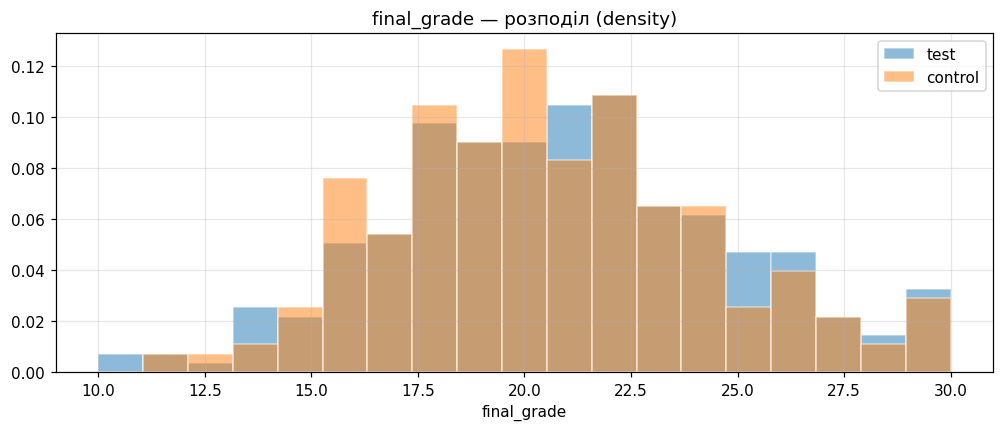

In [19]:
fig, axes = plt.subplots(1, 1, figsize=(11, 4))


bins = np.linspace(df['final_grade'].min(), df['final_grade'].max(), 20)
axes.hist(test['final_grade'], bins=bins, density=True, alpha=0.5, label='test', edgecolor = "white")
axes.hist(control['final_grade'], bins=bins, density=True, alpha=0.5, label='control', edgecolor = "white")
axes.set_title('final_grade — розподіл (density)')
axes.set_xlabel('final_grade')
axes.legend()



desc = df.groupby('arm')['final_grade'].agg(['count','mean','std','median']).round(2)
print(desc)

t, p = stats.ttest_ind(test['final_grade'], control['final_grade'], equal_var=False)
diff = test['final_grade'].mean() - control['final_grade'].mean()
print(f"\nWelch t-test: diff={diff:.3f}, t={t:.3f}, p={p:.4f}")
print(f"Lift у % від бази control: {100*diff/control['final_grade'].mean():.2f}%")

## 2. Proxy metric: `second_quiz`

Швидкий сигнал, що корелює з final_grade — корисний як proxy та для CUPED (розділ 3.10).

         count  mean   std  median
arm                               
control    263  5.95  2.16     6.0
test       263  6.40  2.18     7.0

Welch t-test: diff=0.456, t=2.412, p=0.0162


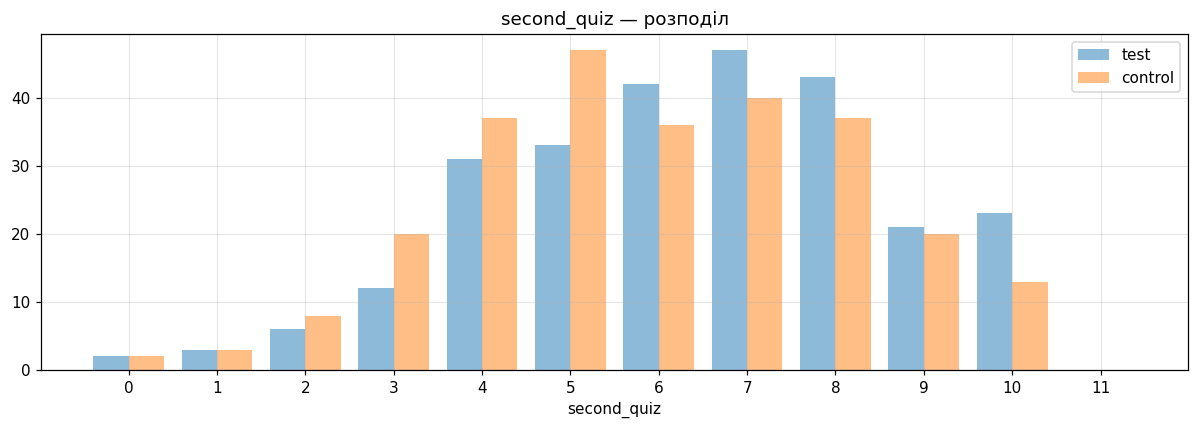

In [20]:
fig, axes = plt.subplots(1, 1, figsize=(11, 4))

vals = np.arange(0, 12)
test_counts = test['second_quiz'].value_counts().reindex(vals, fill_value=0)
control_counts = control['second_quiz'].value_counts().reindex(vals, fill_value=0)
width = 0.4
axes.bar(vals - width/2, test_counts.values, width=width, label='test', alpha = 0.5)
axes.bar(vals + width/2, control_counts.values, width=width, label='control', alpha = 0.5)
axes.set_title('second_quiz — розподіл')
axes.set_xlabel('second_quiz')
axes.set_xticks(vals)
axes.legend()

plt.tight_layout()

print(df.groupby('arm')['second_quiz'].agg(['count','mean','std','median']).round(2))
t, p = stats.ttest_ind(test['second_quiz'], control['second_quiz'], equal_var=False)
print(f"\nWelch t-test: diff={test['second_quiz'].mean()-control['second_quiz'].mean():.3f}, t={t:.3f}, p={p:.4f}")

## 3. Informational metric: `prep_time`

Час на підготовку. Тут цікавий напрямок: чи Fireflies **скорочує** час підготовки при тому самому (або кращому) результаті.

         count   mean    std  median
arm                                 
control    263  72.24  69.70   59.49
test       263  55.09  60.98   35.55

Welch t-test: diff=-17.150, t=-3.003, p=0.0028


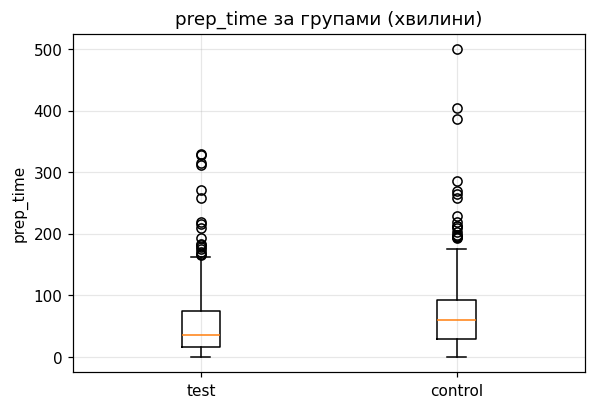

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([test['prep_time'], control['prep_time']], tick_labels=['test', 'control'])
ax.set_title('prep_time за групами (хвилини)')
ax.set_ylabel('prep_time')

print(df.groupby('arm')['prep_time'].agg(['count','mean','std','median']).round(2))
t, p = stats.ttest_ind(test['prep_time'], control['prep_time'], equal_var=False)
print(f"\nWelch t-test: diff={test['prep_time'].mean()-control['prep_time'].mean():.3f}, t={t:.3f}, p={p:.4f}")

У `test_data.csv` є `usage` (скільки часу студент реально користувався Fireflies) — 69 з 263 студентів мають `usage = 0` (не скористались інструментом жодного разу), хоча формально належать до test-групи.

                         count   mean   std
usage_group                                
Не користувались (0 хв)   64.0  18.08  3.41
Мало (0-30 хв)            81.0  20.14  3.02
Регулярно (30+ хв)       118.0  22.82  3.44
Control (довідково)      263.0  20.60  3.61


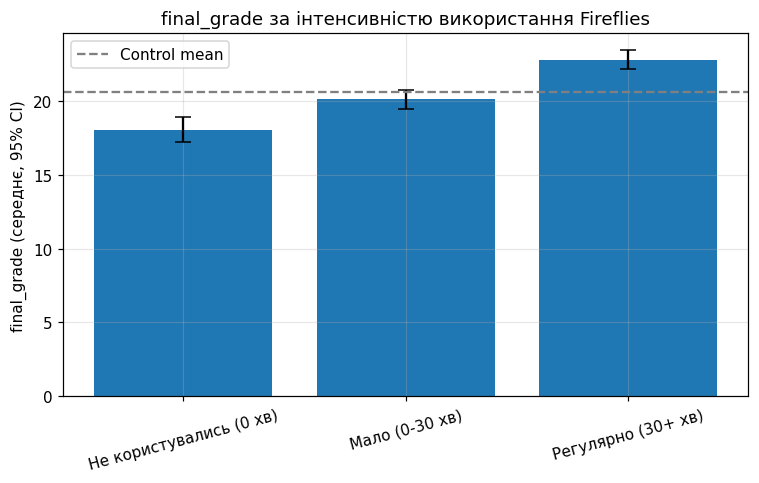

In [22]:
bins_edges = [-0.1, 0, 30, test['usage'].max()]
labels = ['Не користувались (0 хв)', 'Мало (0-30 хв)', 'Регулярно (30+ хв)']
usage_group = pd.cut(test['usage'], bins=bins_edges, labels=labels)
test_binned = test.assign(usage_group=usage_group)

summary = test_binned.groupby('usage_group', observed=False)['final_grade'].agg(['count','mean','std']).round(2)
summary.loc['Control (довідково)'] = [len(control), round(control['final_grade'].mean(),2), round(control['final_grade'].std(),2)]
print(summary)

means = test_binned.groupby('usage_group', observed=False)['final_grade'].mean()
sems = test_binned.groupby('usage_group', observed=False)['final_grade'].sem()

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(means))
ax.bar(x, means.values, yerr=1.96*sems.values, capsize=5)
ax.axhline(control['final_grade'].mean(), color='gray', linestyle='--', label='Control mean')
ax.set_xticks(x)
ax.set_xticklabels(means.index.astype(str), rotation=15)
ax.set_ylabel('final_grade (середнє, 95% CI)')
ax.set_title('final_grade за інтенсивністю використання Fireflies')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Кореляції та розсіювання (usage vs final_grade)

Звертаємо увагу: `usage` і `prep_time` дуже сильно корелюють всередині test-групи (це майже одна й та сама активність), а `SECRET!!!!` — прихована змінна, яку ми не контролюємо (в реальному пілоті таких прихованих факторів здатності/мотивації в даних немає — тому варто явно згадати ризик unobserved confounding у розділі 3.11).

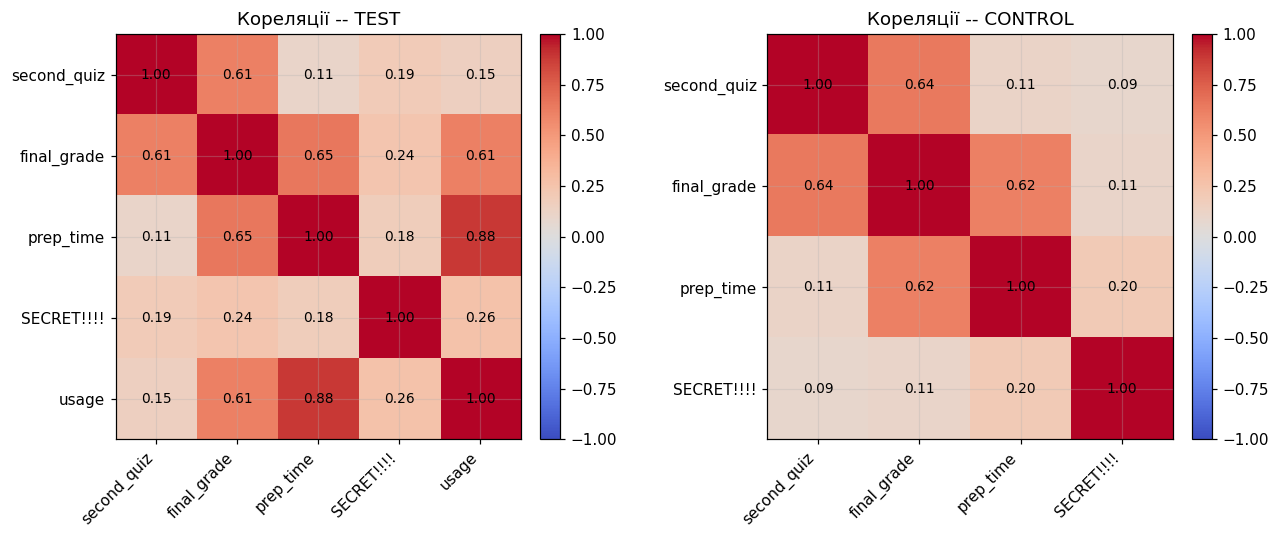

In [23]:
cols_test = ['second_quiz','final_grade','prep_time','SECRET!!!!','usage']
cols_control = ['second_quiz','final_grade','prep_time','SECRET!!!!']

corr_test = test[cols_test].corr()
corr_control = control[cols_control].corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, corr, title in [(axes[0], corr_test, 'Кореляції -- TEST'), (axes[1], corr_control, 'Кореляції -- CONTROL')]:
    im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(corr.columns)
    ax.set_title(title)
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha='center', va='center', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

Pearson r = 0.614, p = 1.286e-28, slope = 0.0408


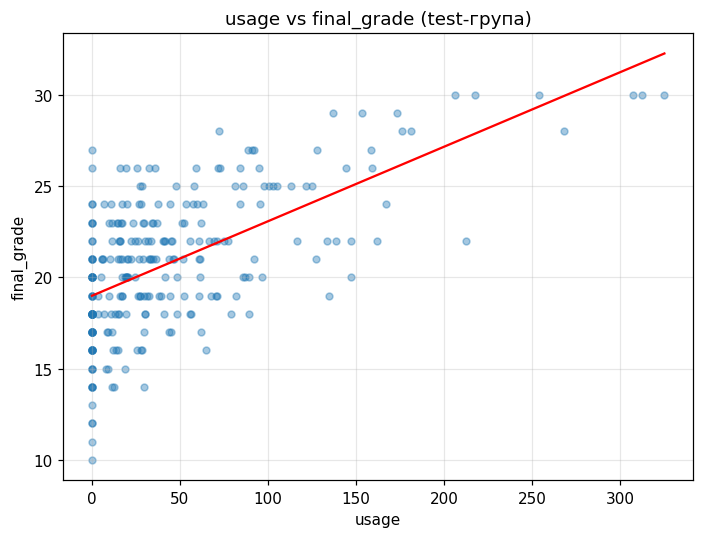

In [24]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(test['usage'], test['final_grade'], alpha=0.4, s=20)

slope, intercept, r, p, se = stats.linregress(test['usage'], test['final_grade'])
xs = np.linspace(test['usage'].min(), test['usage'].max(), 100)
ax.plot(xs, intercept + slope * xs, color='red')

ax.set_xlabel('usage')
ax.set_ylabel('final_grade')
ax.set_title('usage vs final_grade (test-група)')
plt.tight_layout()

print(f"Pearson r = {r:.3f}, p = {p:.4g}, slope = {slope:.4f}")

## 6. Перевірка нормальності

Дані обмежені шкалою (final_grade, second_quiz — бали з верхньою межею), тому варто перевірити форму розподілу, а не одразу брати t-тест за замовчуванням.

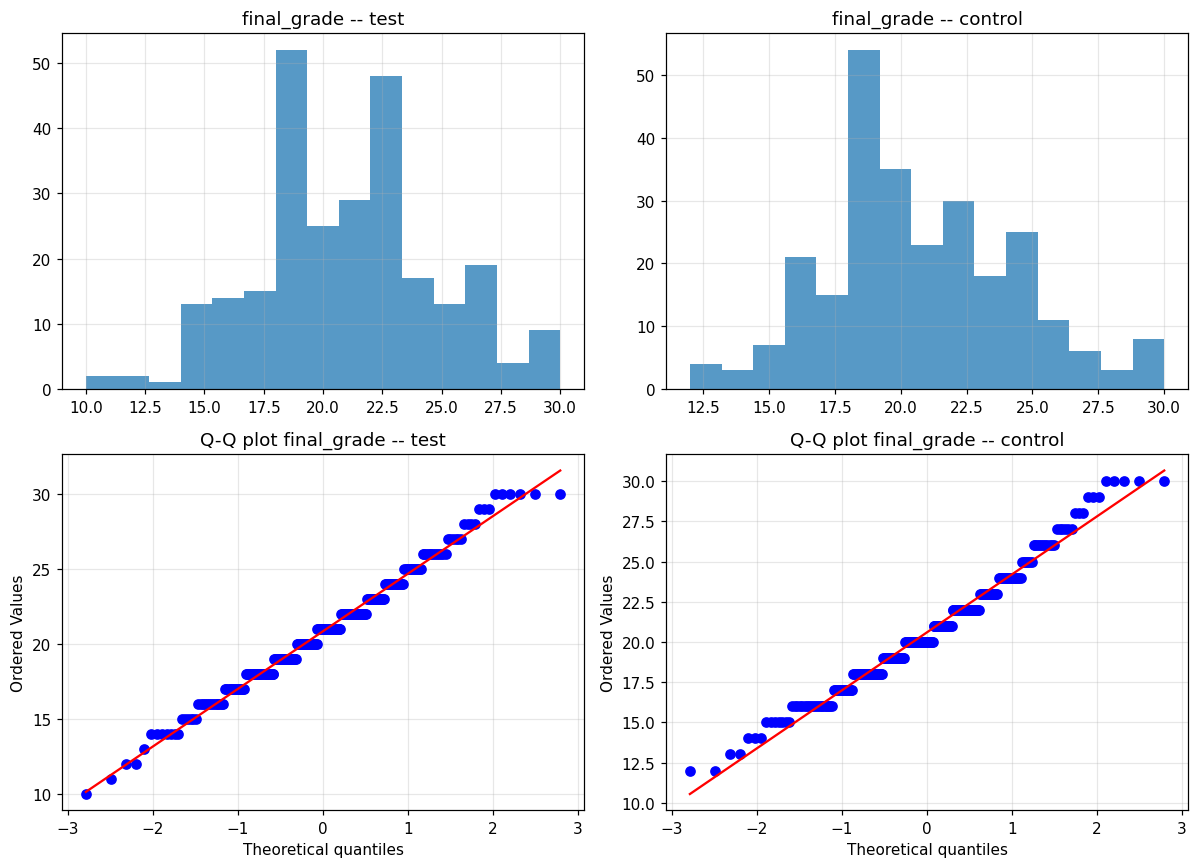

Shapiro-Wilk (test, final_grade): W=0.9889, p=0.0411  -> відхилення від нормальності
  skew=0.127
Shapiro-Wilk (control, final_grade): W=0.9805, p=0.0011  -> відхилення від нормальності
  skew=0.365


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, (arm_name, data) in zip(axes[0], [('test', test), ('control', control)]):
    ax.hist(data['final_grade'], bins=15, alpha=0.75)
    ax.set_title(f'final_grade -- {arm_name}')

for ax, (arm_name, data) in zip(axes[1], [('test', test), ('control', control)]):
    stats.probplot(data['final_grade'], dist="norm", plot=ax)
    ax.set_title(f'Q-Q plot final_grade -- {arm_name}')

plt.tight_layout()
plt.show()

for arm_name, data in [('test', test), ('control', control)]:
    stat, p = stats.shapiro(data['final_grade'])
    print(f"Shapiro-Wilk ({arm_name}, final_grade): W={stat:.4f}, p={p:.4f}  "
          f"{'-> схоже на нормальний' if p > 0.05 else '-> відхилення від нормальності'}")
    print(f"  skew={data['final_grade'].skew():.3f}")

#### Mann-Whitney U


In [26]:
U_scipy, p_scipy = stats.mannwhitneyu(test['final_grade'], control['final_grade'], alternative='two-sided')

print(f"scipy Mann-Whitney:  U={U_scipy:.1f}, p={p_scipy:.4f}")

scipy Mann-Whitney:  U=36145.5, p=0.3688


---
# 3.8 Sample Size and Power

`final_grade` - primary metric. Baseline і std — реальні, з пілотних даних (control-група):

- $\bar{x}_{control} = 20.60$, $s_{control} = 3.61$, $s_{test} = 3.89$ (n = 263 в кожному плечі)
- MDE = 3 відсоткових пункти. Шкала final_grade — 0–30 (це max, який реально спостерігається в обох датасетах), тож 3% = 0.03 × 30 = **0.9 бала абсолютно**. $\alpha = 0.05$, power = 0.8.

In [77]:
alpha = 0.05
power = 0.8
z_alpha = stats.norm.ppf(1 - alpha/2)
z_power = stats.norm.ppf(power)

sd_control = control['final_grade'].std()
sd_test = test['final_grade'].std()
sigma_pooled = np.sqrt((sd_control**2 + sd_test**2) / 2)

mde_abs = 0.9

def required_n(sigma, delta):
    return 2 * (z_alpha + z_power)**2 * sigma**2 / delta**2

n_req = required_n(sigma_pooled, mde_abs)
print(f"sigma_pooled = {sigma_pooled:.3f}")
print(f"Потрібно n на плече (MDE={mde_abs}, pooled sd) = {n_req:.1f}")
print(f"Наявно фактично: n = 263 на плече")
print(f"-> {'ДОСТАТНЬО' if 263 >= n_req else 'НЕДОСТАТНЬО'} (не вистачає ~{max(0, n_req-263):.0f} студентів/плече)" )

sigma_pooled = 3.721
Потрібно n на плече (MDE=0.9, pooled sd) = 268.3
Наявно фактично: n = 263 на плече
-> НЕДОСТАТНЬО (не вистачає ~5 студентів/плече)


Наявний n = 263 майже точно збігається з потрібним - 268. Звідси й прикордонний p-value (0.09) з розділу 1: це не обов'язково "AI не працює", а цілком імовірно "ефект є, але його ледь видно при такому n". Порахуємо навпаки — яку MDE ми реально можемо задетектувати при n=263, і яку потужність маємо для вже спостереженого ефекту (diff=0.55).

In [85]:
mde_det = detectable_mde(263, sigma_pooled)
observed_diff = test['final_grade'].mean() - control['final_grade'].mean()
pw_observed = achieved_power(263, sigma_pooled, observed_diff)

print(f"Детектована MDE при n=263, power=0.8: {mde_det:.3f} або ({100*mde_det/30:.2f} в.п. на шкалі 0-30)")
print(f"Спостережений ефект: {observed_diff:.3f} абс ({100*observed_diff/30:.2f} в.п.)")
print(f"Досягнута потужність для СПОСТЕРЕЖЕНОГО ефекту при n=263: {pw_observed:.3f}")

Детектована MDE при n=263, power=0.8: 0.909 або (3.03 в.п. на шкалі 0-30)
Спостережений ефект: 0.240 абс (0.80 в.п.)
Досягнута потужність для СПОСТЕРЕЖЕНОГО ефекту при n=263: 0.114


`second_quiz` - proxy metric

In [68]:
alpha = 0.05
power = 0.8
z_alpha = stats.norm.ppf(1 - alpha/2)
z_power = stats.norm.ppf(power)

sd_control = control['second_quiz'].std()
sd_test = test['second_quiz'].std()
sigma_pooled = np.sqrt((sd_control**2 + sd_test**2) / 2)

mde_abs = 0.55

n_req = required_n(sigma_pooled, mde_abs)
print(f"sigma_pooled = {sigma_pooled:.3f}")
print(f"Потрібно n на плече (MDE={mde_abs}, pooled sd) = {n_req:.1f}")
print(f"Наявно фактично: n = 263 на плече")
print(f"-> {'ДОСТАТНЬО' if 263 >= n_req else 'НЕДОСТАТНЬО'} (не вистачає ~{max(0, n_req-263):.0f} студентів/плече)" )

sigma_pooled = 2.170
Потрібно n на плече (MDE=0.55, pooled sd) = 244.3
Наявно фактично: n = 263 на плече
-> ДОСТАТНЬО (не вистачає ~0 студентів/плече)


In [75]:
mde_det = detectable_mde(263, sigma_pooled)
observed_diff = test['second_quiz'].mean() - control['second_quiz'].mean()
pw_observed = achieved_power(263, sigma_pooled, observed_diff)

print(f"Детектована MDE при n=263, power=0.8: {mde_det:.3f} або ({100*mde_det/10:.2f} в.п. на шкалі 0-10)")
print(f"Спостережений ефект: {observed_diff:.3f} абс ({100*observed_diff/10:.2f} в.п.)")
print(f"Досягнута потужність для СПОСТЕРЕЖЕНОГО ефекту при n=263: {pw_observed:.3f}")

Детектована MDE при n=263, power=0.8: 0.530 або (5.30 в.п. на шкалі 0-10)
Спостережений ефект: 0.456 абс (4.56 в.п.)
Досягнута потужність для СПОСТЕРЕЖЕНОГО ефекту при n=263: 0.674


**Обґрунтування вибору тесту.** Shapiro-Wilk формально відкидає нормальність в обох плечах (p<0.05), але це типово для n=263 — тест дуже чутливий навіть до дрібних відхилень. Skew (0.13 у test, 0.37 у control) невеликий — форма помірно асиметрична, не патологічна. Welch's t-test (p=0.461) і Mann-Whitney (p=0.369) дають узгоджений висновок (не значущо при α=0.05, і обидва результати далекі від межі) — це підтверджує, що вибір тесту тут не є вирішальним для висновку.

`quardrail metric:` **Проблема з даними:** щоб коректно
поділити студентів на "сильних/слабких", потрібен показник здібності,
виміряний ДО курсу і незалежний від того, в яку групу студент потрапив.
У нас такого поля немає -- `second_quiz` для цього не годиться (сам залежить
від Fireflies, той самий mediator-caveat, що й у CUPED). Єдиний кандидат --
`SECRET!!!!`, і це навмисно **неспостережувана в реальності** змінна (те, що
дослідник ніколи б не побачив у справжньому пілоті).

Тому цей аналіз -- **ілюстративний**: демонструє метод і показує, що сигнал
в принципі можливий, а не production-ready guardrail. У реальному пілоті на
цьому місці має бути GPA / оцінка попереднього семестру.


In [79]:
cutoff = control['SECRET!!!!'].median()
print(f"Поріг (медіана SECRET, control): {cutoff:.3f}")

control['tier'] = np.where(control['SECRET!!!!'] >= cutoff, 'strong', 'weak')
test['tier'] = np.where(test['SECRET!!!!'] >= cutoff, 'strong', 'weak')

print("\ncontrol:", control['tier'].value_counts().to_dict())
print("test:   ", test['tier'].value_counts().to_dict())

combined = pd.concat([control.assign(arm='control'), test.assign(arm='test')])
summary_tbl = combined.groupby(['tier', 'arm'])['final_grade'].agg(['count', 'mean', 'std']).round(3)
print("\n", summary_tbl)

Поріг (медіана SECRET, control): 0.068

control: {'strong': 132, 'weak': 131}
test:    {'strong': 134, 'weak': 129}

                 count    mean    std
tier   arm                          
strong control    132  20.947  3.809
       test       134  21.373  3.581
weak   control    131  20.252  3.382
       test       129  20.287  4.004


In [80]:
effects = {}
for tier in ['weak', 'strong']:
    c = control.loc[control['tier'] == tier, 'final_grade']
    t = test.loc[test['tier'] == tier, 'final_grade']
    diff = t.mean() - c.mean()
    tt, p = stats.ttest_ind(t, c, equal_var=False)
    effects[tier] = diff
    print(f"{tier:7s}: diff={diff:+.3f}, t={tt:.3f}, p={p:.4f}  (n_control={len(c)}, n_test={len(t)})")

weak   : diff=+0.035, t=0.076, p=0.9396  (n_control=131, n_test=129)
strong : diff=+0.426, t=0.940, p=0.3482  (n_control=132, n_test=134)


In [81]:
c_w = control.loc[control['tier'] == 'weak', 'final_grade']
c_s = control.loc[control['tier'] == 'strong', 'final_grade']
t_w = test.loc[test['tier'] == 'weak', 'final_grade']
t_s = test.loc[test['tier'] == 'strong', 'final_grade']

DiD = effects['strong'] - effects['weak']
se_DiD = np.sqrt(
    t_w.var(ddof=1) / len(t_w) + c_w.var(ddof=1) / len(c_w) +
    t_s.var(ddof=1) / len(t_s) + c_s.var(ddof=1) / len(c_s)
)
z = DiD / se_DiD
p_DiD = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"effect_weak   = {effects['weak']:+.3f}")
print(f"effect_strong = {effects['strong']:+.3f}")
print(f"DiD (наскільки сильним AI допоміг більше) = {DiD:+.3f}")
print(f"SE(DiD) = {se_DiD:.3f}, z = {z:.3f}, p = {p_DiD:.4f}")
if p_DiD < 0.05:
    direction = "розширює" if DiD > 0 else "звужує"
    print(f"\n-> ЗНАЧУЩО: Fireflies {direction} розрив між сильними й слабкими студентами.")
else:
    print("\n-> Різниця в ефекті між тірами статистично незначуща -- немає доказів нерівного впливу.")

effect_weak   = +0.035
effect_strong = +0.426
DiD (наскільки сильним AI допоміг більше) = +0.391
SE(DiD) = 0.646, z = 0.606, p = 0.5447

-> Різниця в ефекті між тірами статистично незначуща -- немає доказів нерівного впливу.


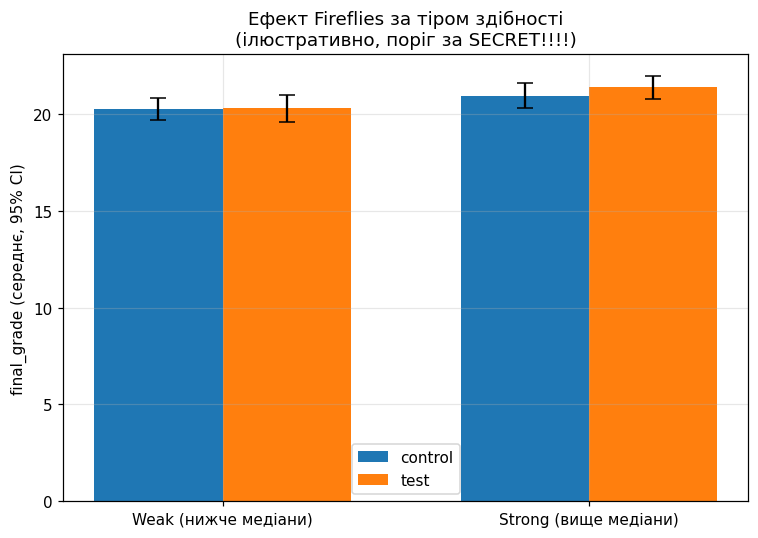

In [82]:
fig, ax = plt.subplots(figsize=(7, 5))
tiers = ['weak', 'strong']
x = np.arange(len(tiers))
width = 0.35

control_means = [control.loc[control['tier'] == t, 'final_grade'].mean() for t in tiers]
control_sems = [control.loc[control['tier'] == t, 'final_grade'].sem() for t in tiers]
test_means = [test.loc[test['tier'] == t, 'final_grade'].mean() for t in tiers]
test_sems = [test.loc[test['tier'] == t, 'final_grade'].sem() for t in tiers]

ax.bar(x - width/2, control_means, width, yerr=1.96*np.array(control_sems), capsize=5, label='control')
ax.bar(x + width/2, test_means, width, yerr=1.96*np.array(test_sems), capsize=5, label='test')
ax.set_xticks(x)
ax.set_xticklabels(['Weak (нижче медіани)', 'Strong (вище медіани)'])
ax.set_ylabel('final_grade (середнє, 95% CI)')
ax.set_title('Ефект Fireflies за тіром здібності\n(ілюстративно, поріг за SECRET!!!!)')
ax.legend()
plt.tight_layout()

In [83]:
q1, q2 = control['SECRET!!!!'].quantile([1/3, 2/3])
print(f"Терцильні межі (control): {q1:.3f} / {q2:.3f}")

for name, df in [('control', control), ('test', test)]:
    df['tercile'] = pd.cut(df['SECRET!!!!'], bins=[-np.inf, q1, q2, np.inf],
                            labels=['bottom', 'middle', 'top'])

for tier_label, low, high in [('weak (bottom 1/3)', 'bottom', 'bottom'), ('strong (top 1/3)', 'top', 'top')]:
    c = control.loc[control['tercile'] == low, 'final_grade']
    t = test.loc[test['tercile'] == high, 'final_grade']
    diff = t.mean() - c.mean()
    tt, p = stats.ttest_ind(t, c, equal_var=False)
    print(f"{tier_label:20s}: diff={diff:+.3f}, p={p:.4f}  (n_control={len(c)}, n_test={len(t)})")

Терцильні межі (control): -0.320 / 0.496
weak (bottom 1/3)   : diff=-0.628, p=0.2521  (n_control=88, n_test=98)
strong (top 1/3)    : diff=+0.409, p=0.4701  (n_control=88, n_test=92)


`guardrail metric` верифікована - немає жодних статистичних відхилень у `test` від `control` - що означає, що інструмент не збільшує різницю між слабкими та сильними учнями

## Simulation-Based Validation

Синтетичні дані отримуємо бутстрепом із реального розподілу `control['final_grade']`.

- **A/A** (1000 симуляцій): обидва "плеча" -- бутстреп з control, без інжектованого ефекту. False-positive rate повинен бути ≈ α = 0.05.
- **A/B** (1000 симуляцій): друге плече = бутстреп з control + константний зсув = MDE (0.9). Detection rate повинен збігатися із заявленою потужністю (0.8) -- принаймні для тесту, який ми обираємо як primary.

Seed фіксований (`42`) для відтворюваності.

In [51]:
SEED = 42
N_SIMS = 1000
N = 263
MDE = mde_abs  # 0.9

from statsmodels.stats.proportion import proportion_confint

rng = np.random.default_rng(SEED)
c_vals = control['final_grade'].values

def rate_with_ci(p_values, alpha=0.05):
    successes = int((p_values < alpha).sum())
    n = len(p_values)
    ci = proportion_confint(successes, n, method = "wilson")
    return successes / n, ci[0], ci[1]
def run_simulation(inject_effect, n_sims=N_SIMS, n=N, rng=rng):
    p_welch = np.empty(n_sims)
    p_mw = np.empty(n_sims)
    p_bm = np.empty(n_sims)
    for i in range(n_sims):
        arm_a = rng.choice(c_vals, size=n, replace=True)
        arm_b = rng.choice(c_vals, size=n, replace=True) + inject_effect
        p_welch[i] = stats.ttest_ind(arm_b, arm_a, equal_var=False).pvalue
        p_mw[i] = stats.mannwhitneyu(arm_b, arm_a, alternative='two-sided').pvalue
        p_bm[i] = stats.brunnermunzel(arm_b, arm_a).pvalue
    return p_welch, p_mw, p_bm

p_welch_aa, p_mw_aa, p_bm_aa = run_simulation(inject_effect=0.0)
p_welch_ab, p_mw_ab, p_bm_ab = run_simulation(inject_effect=MDE)

print("=== A/A: false-positive rate (target ~= 0.05), 95% Wilson CI ===")
for name, p_arr in [("Welch t-test", p_welch_aa), ("Mann-Whitney", p_mw_aa), ("Brunner-Munzel", p_bm_aa)]:
    rate, lo, hi = rate_with_ci(p_arr)
    print(f"  {name:16s} {rate:.3f}  [{lo:.3f}, {hi:.3f}]")

print("\n=== A/B: detection rate = empirical power (target 0.8), 95% Wilson CI ===")
for name, p_arr in [("Welch t-test", p_welch_ab), ("Mann-Whitney", p_mw_ab), ("Brunner-Munzel", p_bm_ab)]:
    rate, lo, hi = rate_with_ci(p_arr)
    print(f"  {name:16s} {rate:.3f}  [{lo:.3f}, {hi:.3f}]")

ks_stat, ks_p = stats.kstest(p_welch_aa, 'uniform')
print(f"\nKS-тест рівномірності p-values (Welch, A/A): stat={ks_stat:.4f}, p={ks_p:.4f}  "
      f"{'-> ОК, узгоджується з рівномірним' if ks_p > 0.05 else '-> відхилення від рівномірного'}")

=== A/A: false-positive rate (target ~= 0.05), 95% Wilson CI ===
  Welch t-test     0.056  [0.043, 0.072]
  Mann-Whitney     0.060  [0.047, 0.076]
  Brunner-Munzel   0.062  [0.049, 0.079]

=== A/B: detection rate = empirical power (target 0.8), 95% Wilson CI ===
  Welch t-test     0.825  [0.800, 0.847]
  Mann-Whitney     0.376  [0.347, 0.406]
  Brunner-Munzel   0.376  [0.347, 0.406]

KS-тест рівномірності p-values (Welch, A/A): stat=0.0320, p=0.2530  -> ОК, узгоджується з рівномірним


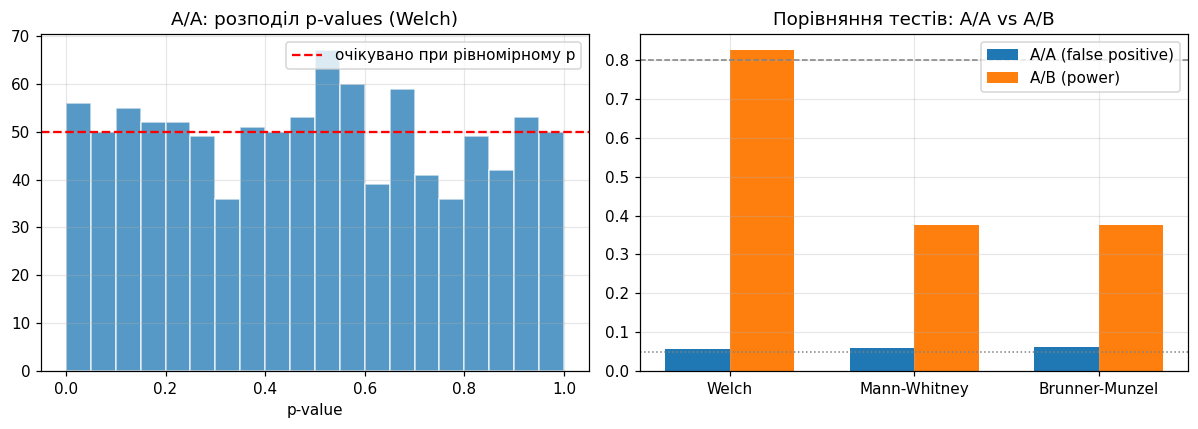

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(p_welch_aa, bins=20, range=(0,1), alpha=0.75, edgecolor='white')
axes[0].axhline(N_SIMS/20, color='red', linestyle='--', label='очікувано при рівномірному p')
axes[0].set_title('A/A: розподіл p-values (Welch)')
axes[0].set_xlabel('p-value')
axes[0].legend()

labels = ['Welch', 'Mann-Whitney', 'Brunner-Munzel']
aa_rates = [(p_welch_aa<alpha).mean(), (p_mw_aa<alpha).mean(), (p_bm_aa<alpha).mean()]
ab_rates = [(p_welch_ab<alpha).mean(), (p_mw_ab<alpha).mean(), (p_bm_ab<alpha).mean()]
x = np.arange(3)
width = 0.35
axes[1].bar(x - width/2, aa_rates, width, label='A/A (false positive)')
axes[1].bar(x + width/2, ab_rates, width, label='A/B (power)')
axes[1].axhline(alpha, color='gray', linestyle=':', linewidth=1)
axes[1].axhline(power, color='gray', linestyle='--', linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title('Порівняння тестів: A/A vs A/B')
axes[1].legend()

plt.tight_layout()

Для `second_quiz`:

In [73]:
SEED = 42
N_SIMS = 1000
N = 263
MDE = 0.55  # 0.9

from statsmodels.stats.proportion import proportion_confint

rng = np.random.default_rng(SEED)
c_vals = control['second_quiz'].values

def rate_with_ci(p_values, alpha=0.05):
    successes = int((p_values < alpha).sum())
    n = len(p_values)
    ci = proportion_confint(successes, n, method = "wilson")
    return successes / n, ci[0], ci[1]
def run_simulation(inject_effect, n_sims=N_SIMS, n=N, rng=rng):
    p_welch = np.empty(n_sims)
    p_mw = np.empty(n_sims)
    p_bm = np.empty(n_sims)
    for i in range(n_sims):
        arm_a = rng.choice(c_vals, size=n, replace=True)
        arm_b = rng.choice(c_vals, size=n, replace=True) + inject_effect
        p_welch[i] = stats.ttest_ind(arm_b, arm_a, equal_var=False).pvalue
        p_mw[i] = stats.mannwhitneyu(arm_b, arm_a, alternative='two-sided').pvalue
        p_bm[i] = stats.brunnermunzel(arm_b, arm_a).pvalue
    return p_welch, p_mw, p_bm

p_welch_aa, p_mw_aa, p_bm_aa = run_simulation(inject_effect=0.0)
p_welch_ab, p_mw_ab, p_bm_ab = run_simulation(inject_effect=MDE)

print("=== A/A: false-positive rate (target ~= 0.05), 95% Wilson CI ===")
for name, p_arr in [("Welch t-test", p_welch_aa), ("Mann-Whitney", p_mw_aa), ("Brunner-Munzel", p_bm_aa)]:
    rate, lo, hi = rate_with_ci(p_arr)
    print(f"  {name:16s} {rate:.3f}  [{lo:.3f}, {hi:.3f}]")

print("\n=== A/B: detection rate = empirical power (target 0.8), 95% Wilson CI ===")
for name, p_arr in [("Welch t-test", p_welch_ab), ("Mann-Whitney", p_mw_ab), ("Brunner-Munzel", p_bm_ab)]:
    rate, lo, hi = rate_with_ci(p_arr)
    print(f"  {name:16s} {rate:.3f}  [{lo:.3f}, {hi:.3f}]")

ks_stat, ks_p = stats.kstest(p_welch_aa, 'uniform')
print(f"\nKS-тест рівномірності p-values (Welch, A/A): stat={ks_stat:.4f}, p={ks_p:.4f}  "
      f"{'-> ОК, узгоджується з рівномірним' if ks_p > 0.05 else '-> відхилення від рівномірного'}")

=== A/A: false-positive rate (target ~= 0.05), 95% Wilson CI ===
  Welch t-test     0.052  [0.040, 0.068]
  Mann-Whitney     0.053  [0.041, 0.069]
  Brunner-Munzel   0.053  [0.041, 0.069]

=== A/B: detection rate = empirical power (target 0.8), 95% Wilson CI ===
  Welch t-test     0.828  [0.803, 0.850]
  Mann-Whitney     0.720  [0.691, 0.747]
  Brunner-Munzel   0.718  [0.689, 0.745]

KS-тест рівномірності p-values (Welch, A/A): stat=0.0247, p=0.5682  -> ОК, узгоджується з рівномірним


**Висновок для 3.9:** Welch's t-test у симуляції дає false-positive rate = 0.056 [0.043, 0.072] і power = 0.825 [0.800, 0.847] (95% Wilson CI) — точно відповідає заявленим гіперпараметрам, і його варто заявити як primary test. Mann-Whitney / Brunner-Munzel тримають правильний false-positive rate (≈0.05, тест коректний), але мають істотно нижчу потужність на цій конкретній формі розподілу (~0.38, CI не перетинається з 0.8) — тобто вони чесні, але для однакового MDE знадобився б значно більший n.

## 3.10 Variance Reduction (CUPED)
**Кандидат на коваріату:** `second_quiz`, бо корелює з `final_grade`. CUPED
вимагає, щоб `X` було виміряне до початку експерименту (тобто не залежало від
того, в яку групу потрапив студент). У нас `second_quiz` вимірюється під
час курсу — і test-група показує в ньому статистично значущу різницю у Пункті 2. Тобто частина ефекту Fireflies проходить і через `second_quiz`, і він не є чистим pre-experiment коваріатом. Нижче побачимо: дисперсія падає добре, але
точкова оцінка ефекту на CUPED-adjusted даних змінюється - це і є практична
демонстрація того, чому такий вибір коваріати треба явно застерегти.

In [41]:
X_c = control['second_quiz'].values
Y_c = control['final_grade'].values
X_t = test['second_quiz'].values
Y_t = test['final_grade'].values

X_bar = X_c.mean()

theta = np.cov(X_c, Y_c, ddof=1)[0, 1] / np.var(X_c, ddof=1)
rho = np.corrcoef(X_c, Y_c)[0, 1]

print(f"theta = {theta:.4f}")
print(f"rho (corr second_quiz vs final_grade, control) = {rho:.4f}")
print(f"Теоретичне зменшення дисперсії: 1 - rho^2 = {1 - rho**2:.3f}  (тобто -{100*rho**2:.1f}%)")

theta = 1.0752
rho (corr second_quiz vs final_grade, control) = 0.6437
Теоретичне зменшення дисперсії: 1 - rho^2 = 0.586  (тобто -41.4%)


std(final_grade), control: raw=3.612 -> adjusted=2.765
std(final_grade), test:    raw=3.826 -> adjusted=3.032
Фактичне зменшення дисперсії (control): 41.4%


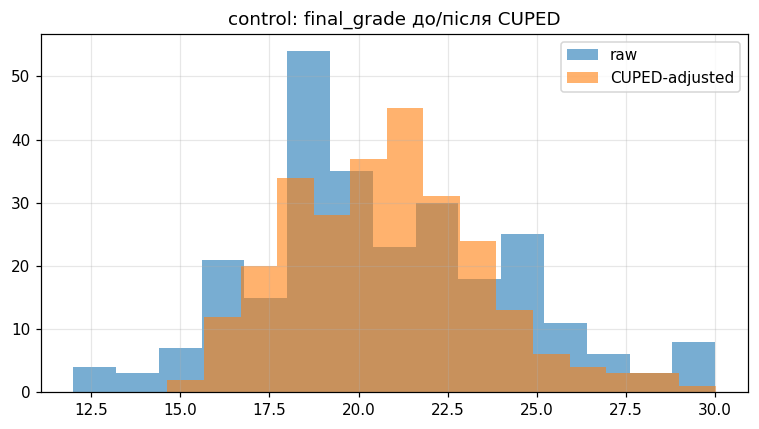

In [55]:
adj_control = Y_c - theta * (X_c - X_bar)
adj_test = Y_t - theta * (X_t - X_bar)

var_before = Y_c.var(ddof=1)
var_after = adj_control.var(ddof=1)

print(f"std(final_grade), control: raw={Y_c.std(ddof=1):.3f} -> adjusted={adj_control.std(ddof=1):.3f}")
print(f"std(final_grade), test:    raw={Y_t.std(ddof=1):.3f} -> adjusted={adj_test.std(ddof=1):.3f}")
print(f"Фактичне зменшення дисперсії (control): {100*(1 - var_after/var_before):.1f}%")

fig, axes = plt.subplots(figsize=(7, 4))
axes.hist(Y_c, bins=15, alpha=0.6, label='raw')
axes.hist(adj_control, bins=15, alpha=0.6, label='CUPED-adjusted')
axes.set_title('control: final_grade до/після CUPED')
axes.legend()

plt.tight_layout()

In [56]:
sigma_raw = Y_c.std(ddof=1)
n_req_raw = required_n(sigma_raw, mde_abs)
n_req_cuped = n_req_raw * (1 - rho**2)

print(f"Потрібно n на плече БЕЗ CUPED:  {n_req_raw:.1f}")
print(f"Потрібно n на плече З CUPED:    {n_req_cuped:.1f}")
print(f"Економія: {100*(1 - n_req_cuped/n_req_raw):.1f}% студентів на плече")

Потрібно n на плече БЕЗ CUPED:  252.9
Потрібно n на плече З CUPED:    148.1
Економія: 41.4% студентів на плече


In [59]:
t_raw = stats.ttest_ind(Y_t, Y_c, equal_var=False)
t_adj = stats.ttest_ind(adj_test, adj_control, equal_var=False)

print("=== БЕЗ CUPED ===")
print(f"diff = {Y_t.mean() - Y_c.mean():.3f}, p = {t_raw.pvalue:.4f}")

print("\n=== З CUPED ===")
print(f"diff = {adj_test.mean() - adj_control.mean():.3f}, p = {t_adj.pvalue:.4f}")

=== БЕЗ CUPED ===
diff = 0.240, p = 0.4607

=== З CUPED ===
diff = -0.251, p = 0.3215


Бачимо, що змінилися знаки - тобто при використанні коваріати ми відняли не тільки шум, але й справжній сигнал разом з нею, як і очікувалось в результаті використання залежної фічі.

In [60]:
SEED_CUPED = 42
N_SIMS = 1000
N = 263

rng_cuped = np.random.default_rng(SEED_CUPED)
paired_control = control[['second_quiz', 'final_grade']].values

def run_cuped_simulation(inject_effect, n_sims=N_SIMS, n=N, rng=rng_cuped):
    p_raw = np.empty(n_sims)
    p_cuped = np.empty(n_sims)
    for i in range(n_sims):
        idx_a = rng.integers(0, len(paired_control), size=n)
        idx_b = rng.integers(0, len(paired_control), size=n)
        Xa, Ya = paired_control[idx_a, 0], paired_control[idx_a, 1]
        Xb, Yb = paired_control[idx_b, 0], paired_control[idx_b, 1] + inject_effect

        p_raw[i] = stats.ttest_ind(Yb, Ya, equal_var=False).pvalue

        Ya_adj = Ya - theta * (Xa - X_bar)
        Yb_adj = Yb - theta * (Xb - X_bar)
        p_cuped[i] = stats.ttest_ind(Yb_adj, Ya_adj, equal_var=False).pvalue
    return p_raw, p_cuped

p_raw_ab, p_cuped_ab = run_cuped_simulation(inject_effect=mde_abs)

rate_raw, lo_raw, hi_raw = rate_with_ci(p_raw_ab)
rate_cuped, lo_cuped, hi_cuped = rate_with_ci(p_cuped_ab)

print(f"Power БЕЗ CUPED (n=263):  {rate_raw:.3f}  [{lo_raw:.3f}, {hi_raw:.3f}]")
print(f"Power З CUPED (n=263):    {rate_cuped:.3f}  [{lo_cuped:.3f}, {hi_cuped:.3f}]")

Power БЕЗ CUPED (n=263):  0.814  [0.789, 0.837]
Power З CUPED (n=263):    0.959  [0.945, 0.970]


У цьому тесті не було використано фічі з проблематикою, а симулювалося використання спражнього коваріату, тому цим результатам можна довіряти.

**Висновок для 3.10:** Протестували CUPED на вибраній фічі - `second_quiz`. Результат незадовільний - хоч і `varience` понижається на 41.4%, але перегляд lift-у показує, що вибрана фіча зменшує не тільки шум, а й справжній сигнал, що є результатом того, що `second_quiz` виміряний під час тестування а не завчасно. На бали може впливати як використання `Fireflies`, так і загальне знання студента. Якби фіча була б зроблена до початку курсу - до використання `Fireflies`, то зменшувалась би коваріація знань, а так ми також замішуємо і коваріацію використання `Fireflies`. Це ще видно з Пункту 2, де тест показує відчутну різницю між балами `second_quiz` між `control` та `test`.